# Phishing Email Detection using Machine Learning and Explainable AI

This notebook implements the proposed methodology for detecting phishing emails using traditional machine learning models and DistilBERT. The models are evaluated on both traditional phishing emails and AI-generated phishing emails. SHAP and LIME are used to explain model predictions.

# Import Required Libraries

Import the libraries required for data loading, analysis, and visualisation

In [1]:
!pip install -q transformers datasets accelerate evaluate

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

# Load Datasets

Load the datasets used throughout this study

In [3]:
# Load datasets

enron_df = pd.read_csv("Enron.csv")
ceas_df = pd.read_csv("CEAS_08.csv")
nazario_df = pd.read_csv("Nazario.csv")
llm_df = pd.read_csv("LLM_Generated.csv")

# Store datasets

datasets = {
    "Enron": enron_df,
    "CEAS_08": ceas_df,
    "Nazario": nazario_df,
    "LLM Generated": llm_df
}

# Display dataset information

for name, df in datasets.items():

    print(f"\n{name}")

    print(f"Shape : {df.shape}")

    display(df.head())


Enron
Shape : (29767, 3)


,subject,body,label
0,"hpl nom for may 25 , 2001",( see attached file : hplno 525 . xls )\r\n- h...,0
1,re : nom / actual vols for 24 th,- - - - - - - - - - - - - - - - - - - - - - fo...,0
2,"enron actuals for march 30 - april 1 , 201","estimated actuals\r\nmarch 30 , 2001\r\nno flo...",0
3,"hpl nom for may 30 , 2001",( see attached file : hplno 530 . xls )\r\n- h...,0
4,"hpl nom for june 1 , 2001",( see attached file : hplno 601 . xls )\r\n- h...,0



CEAS_08
Shape : (39154, 7)


,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1



Nazario
Shape : (1565, 7)


,sender,receiver,date,subject,body,urls,label
0,Mail System Internal Data <MAILER-DAEMON@monke...,NaN,28 Sep 2017 09:57:25 -0400,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL DATA,This text is part of the internal format of yo...,1,1
1,cPanel <service@cpanel.com>,jose@monkey.org,"Fri, 30 Oct 2015 00:00:48 -0500",Verify Your Account,Business with \t\t\t\t\t\t\t\tcPanel & WHM \t...,1,1
2,Microsoft Outlook <recepcao@unimedceara.com.br>,NaN,"Fri, 30 Oct 2015 06:21:59 -0300 (BRT)",Helpdesk Mailbox Alert!!!,Your two incoming mails were placed on pending...,1,1
3,Ann Garcia <AnGarcia@mcoe.org>,"""info@maaaaa.org"" <info@maaaaa.org>","Fri, 30 Oct 2015 14:54:33 +0000",IT-Service Help Desk,Password will expire in 3 days. Click Here To ...,0,1
4,"""USAA"" <usaaacctupdate@sccu4u.com>",Recipients <usaaacctupdate@sccu4u.com>,"Fri, 30 Oct 2015 14:02:33 -0500",Final USAA Reminder - Update Your Account Now,"To ensure delivery to your inbox, please add U...",1,1



LLM Generated
Shape : (1000, 4)


,category,subject,body,label
0,Password Reset,Reminder: Security Reset,As part of a routine security review regarding...,1
1,Microsoft 365,Urgent: License Renewal,We detected license renewal. Please verify you...,1
2,Amazon,Attention: Security Review,We require confirmation following security rev...,1
3,Invoice/Payment,Notice: Finance Review,We detected finance review. Please verify your...,1
4,PayPal,Final Reminder: Security Check,Our monitoring systems identified security che...,1


# Exploratory Data Analysis

Explore the datasets before preprocessing.

In [4]:
for name, df in datasets.items():

    print(f"\n{name}")


    print("Columns")
    print(df.columns.tolist())

    print("\nMissing Values")
    print(df.isnull().sum())

    print("\nDuplicate Records")
    print(df.duplicated().sum())


Enron
Columns
['subject', 'body', 'label']

Missing Values
subject    198
body         0
label        0
dtype: int64

Duplicate Records
0

CEAS_08
Columns
['sender', 'receiver', 'date', 'subject', 'body', 'label', 'urls']

Missing Values
sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

Duplicate Records
0

Nazario
Columns
['sender', 'receiver', 'date', 'subject', 'body', 'urls', 'label']

Missing Values
sender       0
receiver    96
date         1
subject      4
body         0
urls         0
label        0
dtype: int64

Duplicate Records
0

LLM Generated
Columns
['category', 'subject', 'body', 'label']

Missing Values
category    0
subject     0
body        0
label       0
dtype: int64

Duplicate Records
99


### Class Distribution

Visualise the number of legitimate and phishing emails in each dataset.

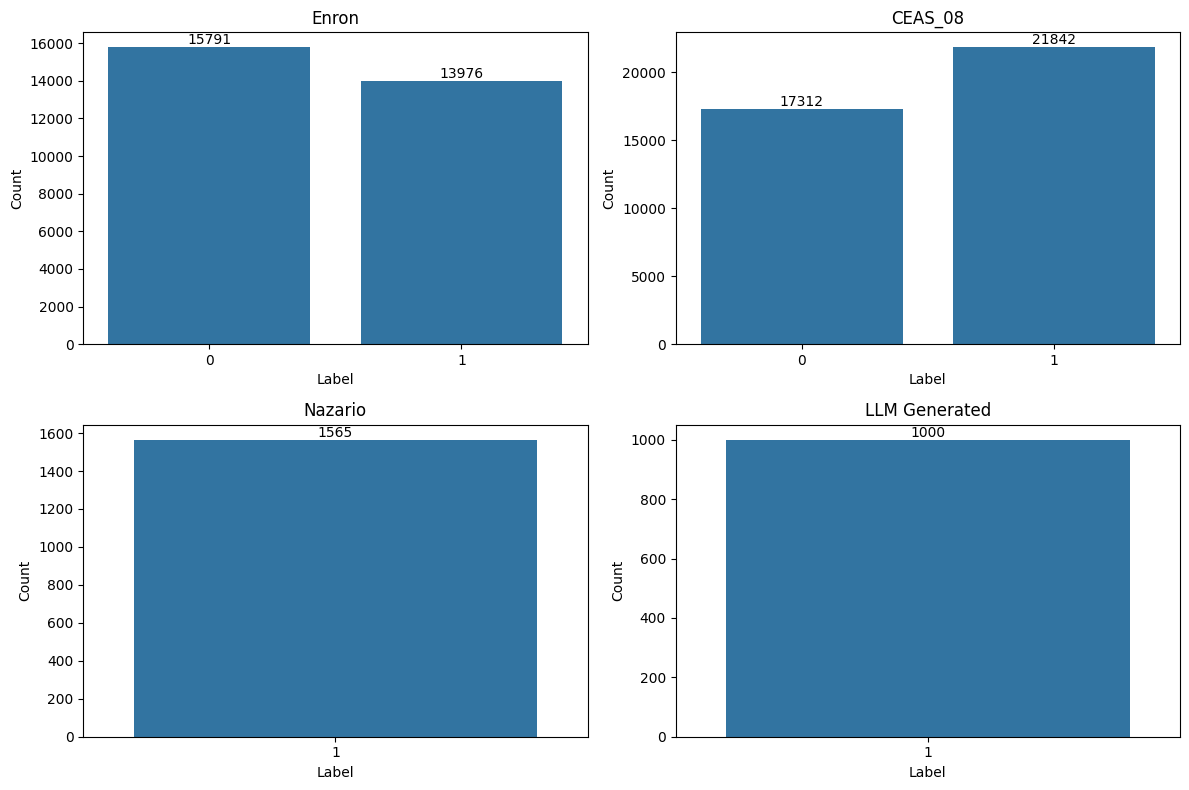

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, (name, df) in zip(axes.flatten(), datasets.items()):

    sns.countplot(data=df, x="label", ax=ax)

    ax.set_title(name)
    ax.set_xlabel("Label")
    ax.set_ylabel("Count")

    # Add values on bars
    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()

### Missing Values

Compare missing values across the datasets.

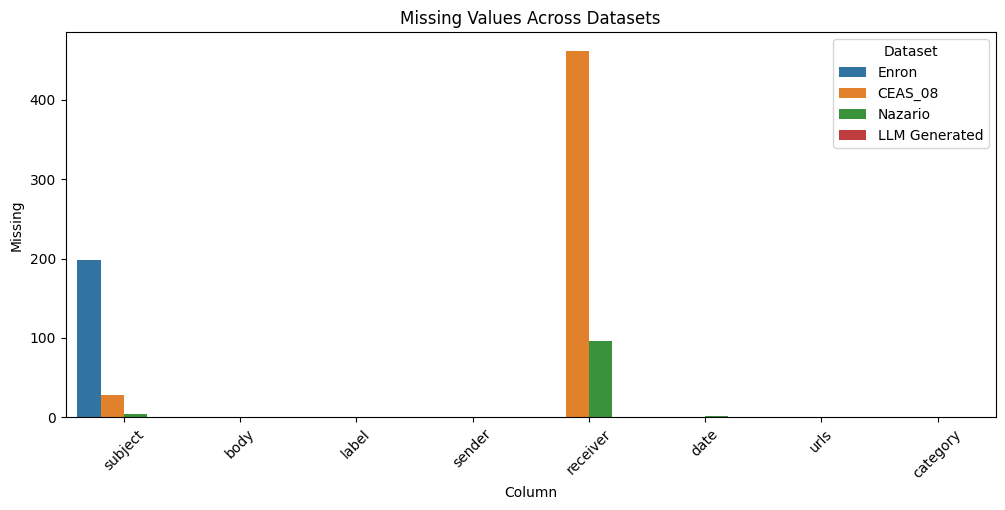

In [6]:
missing = []

for name, df in datasets.items():

    for column in df.columns:

        missing.append({

            "Dataset": name,
            "Column": column,
            "Missing": df[column].isnull().sum()

        })

missing_df = pd.DataFrame(missing)

plt.figure(figsize=(12,5))

sns.barplot(
    data=missing_df,
    x="Column",
    y="Missing",
    hue="Dataset"
)

plt.title("Missing Values Across Datasets")

plt.xticks(rotation=45)

plt.show()

### Duplicate Records

Compare duplicate records across all datasets.

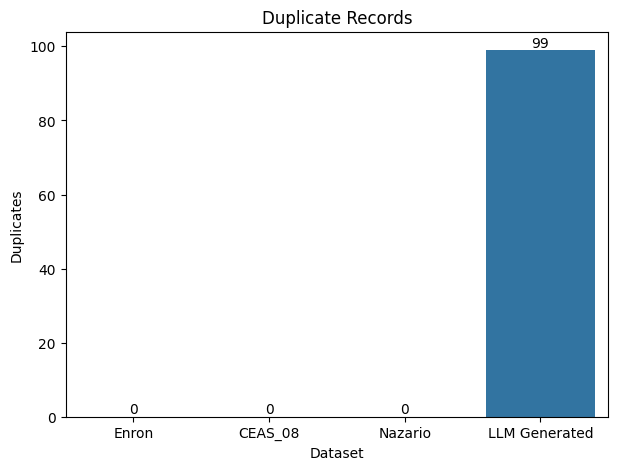

In [7]:
duplicate_df = pd.DataFrame({

    "Dataset": datasets.keys(),

    "Duplicates": [

        df.duplicated().sum()

        for df in datasets.values()

    ]

})

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=duplicate_df,
    x="Dataset",
    y="Duplicates"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Duplicate Records")

plt.show()

# Data Cleaning

Prepare the datasets by selecting the required columns, handling missing values, and removing duplicate records.

In [8]:
# Keep required columns

enron_clean = enron_df[['subject', 'body', 'label']].copy()
ceas_clean = ceas_df[['subject', 'body', 'label']].copy()
nazario_clean = nazario_df[['subject', 'body', 'label']].copy()
llm_clean = llm_df[['subject', 'body', 'label']].copy()

# Handle missing subjects

enron_clean["subject"] = enron_clean["subject"].fillna("")
ceas_clean["subject"] = ceas_clean["subject"].fillna("")
nazario_clean["subject"] = nazario_clean["subject"].fillna("")

# Remove duplicates

duplicates = llm_clean.duplicated().sum()

llm_clean = llm_clean.drop_duplicates().reset_index(drop=True)

print(f"Duplicate emails removed from LLM dataset: {duplicates}")

# Display cleaned dataset shapes

for name, df in {

    "Enron": enron_clean,

    "CEAS_08": ceas_clean,

    "Nazario": nazario_clean,

    "LLM Generated": llm_clean

}.items():

    print(f"{name}: {df.shape}")

Duplicate emails removed from LLM dataset: 99
Enron: (29767, 3)
CEAS_08: (39154, 3)
Nazario: (1565, 3)
LLM Generated: (901, 3)


# Text Preprocessing

Combine the email subject and body into a single text column for model training.

In [9]:
for dataset in [

    enron_clean,

    ceas_clean,

    nazario_clean,

    llm_clean

]:

    dataset["text"] = (

        dataset["subject"].fillna("").astype(str)

        + " " +

        dataset["body"].fillna("").astype(str)

    ).str.strip()

# Preview

for name, df in {

    "Enron": enron_clean,

    "CEAS_08": ceas_clean,

    "Nazario": nazario_clean,

    "LLM Generated": llm_clean

}.items():

    print(f"\n{name}")

    display(df[["text", "label"]].head())


Enron


,text,label
0,"hpl nom for may 25 , 2001 ( see attached file ...",0
1,re : nom / actual vols for 24 th - - - - - - -...,0
2,"enron actuals for march 30 - april 1 , 201 est...",0
3,"hpl nom for may 30 , 2001 ( see attached file ...",0
4,"hpl nom for june 1 , 2001 ( see attached file ...",0



CEAS_08


,text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1



Nazario


,text,label
0,DON'T DELETE THIS MESSAGE -- FOLDER INTERNAL D...,1
1,Verify Your Account Business with \t\t\t\t\t\...,1
2,Helpdesk Mailbox Alert!!! Your two incoming ma...,1
3,IT-Service Help Desk Password will expire in 3...,1
4,Final USAA Reminder - Update Your Account Now ...,1



LLM Generated


,text,label
0,Reminder: Security Reset As part of a routine ...,1
1,Urgent: License Renewal We detected license re...,1
2,Attention: Security Review We require confirma...,1
3,Notice: Finance Review We detected finance rev...,1
4,Final Reminder: Security Check Our monitoring ...,1


# Prepare Datasets

Create the datasets used in the experiments.

In [10]:
traditional_dataset = pd.concat(

    [enron_clean, ceas_clean, nazario_clean],

    ignore_index=True

)

mixed_dataset = pd.concat(

    [traditional_dataset, llm_clean],

    ignore_index=True

)

print("Traditional Dataset :", traditional_dataset.shape)

print("Mixed Dataset :", mixed_dataset.shape)

Traditional Dataset : (70486, 4)
Mixed Dataset : (71387, 4)


### Dataset Distribution

Compare the class distribution after combining the datasets.

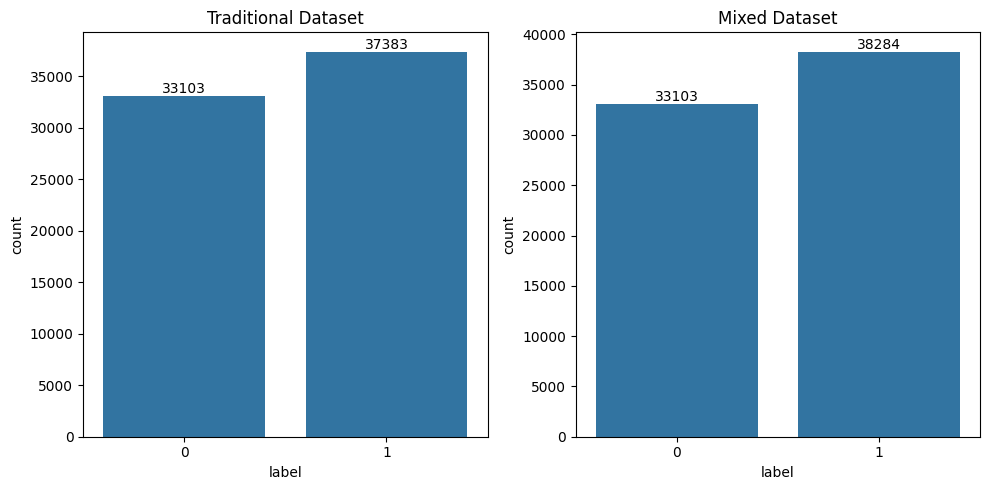

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))

sns.countplot(

    data=traditional_dataset,

    x="label",

    ax=axes[0]

)

axes[0].set_title("Traditional Dataset")

for container in axes[0].containers:
    axes[0].bar_label(container)

sns.countplot(

    data=mixed_dataset,

    x="label",

    ax=axes[1]

)

axes[1].set_title("Mixed Dataset")

for container in axes[1].containers:
    axes[1].bar_label(container)

plt.tight_layout()

plt.show()

# Feature Extraction using TF-IDF

Convert the email text into numerical features using the TF-IDF vectorizer. These features will be used to train the traditional machine learning models.

In [12]:
#import required libraries
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import time

In [13]:
# Split features and labels

X = traditional_dataset["text"]
y = traditional_dataset["label"]

# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Convert text into TF-IDF features

tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training Features:", X_train_tfidf.shape)
print("Testing Features :", X_test_tfidf.shape)

Training Features: (56388, 5000)
Testing Features : (14098, 5000)


### Train-Test Split

Visualise the number of samples used for training and testing.

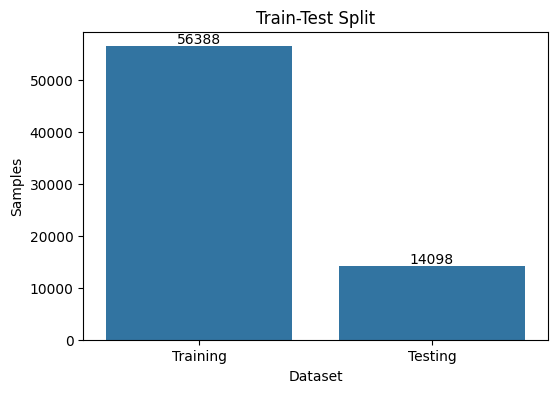

In [14]:
split_df = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Samples": [len(X_train), len(X_test)]
})

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=split_df,
    x="Dataset",
    y="Samples"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Train-Test Split")

plt.show()

# Traditional Machine Learning Models

Train and evaluate five traditional machine learning models using TF-IDF features.

## Logistic Regression

Train and evaluate the Logistic Regression model using TF-IDF features.

In [15]:
from sklearn.linear_model import LogisticRegression

# Train the Logistic Regression model

lr = LogisticRegression(random_state=42)

lr.fit(X_train_tfidf, y_train)

LogisticRegression(random_state=42)

In [16]:
# Predict the test data

lr_predictions = lr.predict(X_test_tfidf)

# Predict probabilities for ROC curve

lr_probabilities = lr.predict_proba(X_test_tfidf)[:, 1]

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Calculate evaluation metrics

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(y_test, lr_predictions)
lr_recall = recall_score(y_test, lr_predictions)
lr_f1 = f1_score(y_test, lr_predictions)
lr_auc = roc_auc_score(y_test, lr_probabilities)

# Display results

print("Accuracy :", round(lr_accuracy,4))
print("Precision:", round(lr_precision,4))
print("Recall   :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))
print("ROC AUC  :", round(lr_auc,4))

print("\nClassification Report\n")
print(classification_report(y_test, lr_predictions))

Accuracy : 0.9847
Precision: 0.9807
Recall   : 0.9908
F1 Score : 0.9857
ROC AUC  : 0.9983

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      6621
           1       0.98      0.99      0.99      7477

    accuracy                           0.98     14098
   macro avg       0.99      0.98      0.98     14098
weighted avg       0.98      0.98      0.98     14098



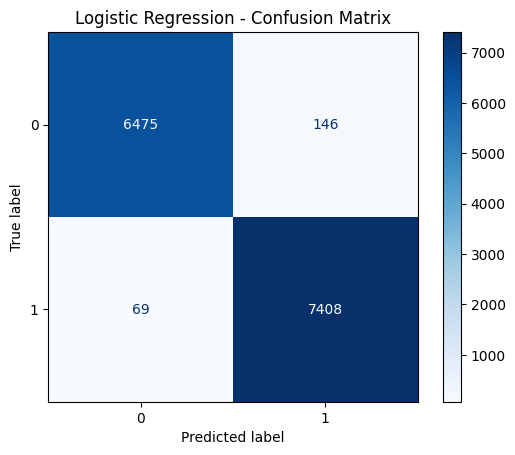

In [18]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    lr_predictions,
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")

plt.show()

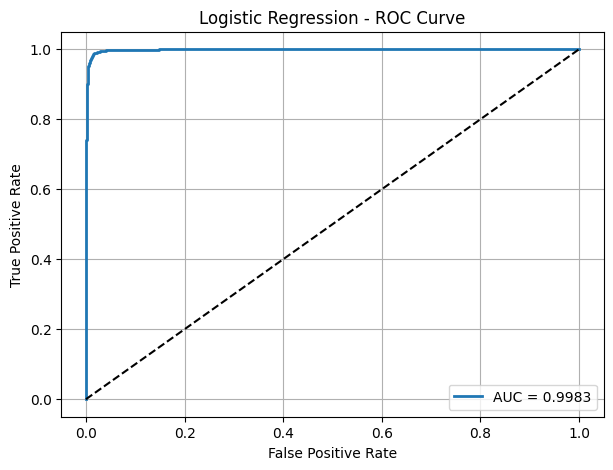

In [19]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    lr_probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {lr_auc:.4f}",
    linewidth=2
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Logistic Regression - ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [20]:
# Create an empty table to store model performance

model_results = pd.DataFrame(columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC AUC",
    "Training Time (s)"
])

model_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)


In [21]:
# Save the results

model_results.loc[len(model_results)] = {
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1 Score": lr_f1,
    "ROC AUC": lr_auc
}

## Naïve Bayes

Train and evaluate the Multinomial Naïve Bayes model using TF-IDF features.

In [22]:
from sklearn.naive_bayes import MultinomialNB

# Train the Naïve Bayes model

nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train)

MultinomialNB()

In [23]:
# Predict the test data

nb_predictions = nb.predict(X_test_tfidf)

# Predict probabilities for ROC curve

nb_probabilities = nb.predict_proba(X_test_tfidf)[:, 1]

In [24]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Calculate evaluation metrics

nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(y_test, nb_predictions)
nb_recall = recall_score(y_test, nb_predictions)
nb_f1 = f1_score(y_test, nb_predictions)
nb_auc = roc_auc_score(y_test, nb_probabilities)

# Display results

metrics = {
    "Accuracy": nb_accuracy,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1 Score": nb_f1,
    "ROC AUC": nb_auc
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, nb_predictions))

Accuracy: 0.9657
Precision: 0.9767
Recall: 0.9583
F1 Score: 0.9674
ROC AUC: 0.9950

Classification Report

              precision    recall  f1-score   support

           0       0.95      0.97      0.96      6621
           1       0.98      0.96      0.97      7477

    accuracy                           0.97     14098
   macro avg       0.97      0.97      0.97     14098
weighted avg       0.97      0.97      0.97     14098



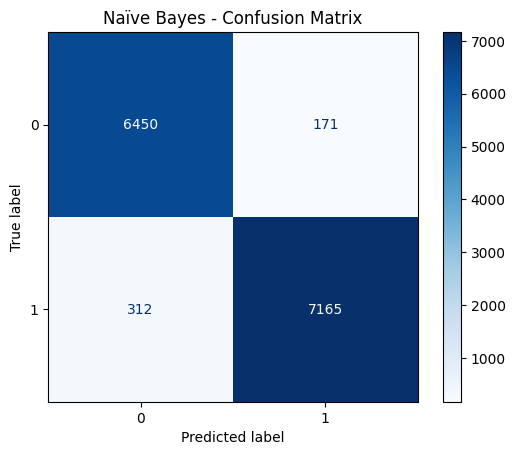

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    nb_predictions,
    cmap="Blues"
)

plt.title("Naïve Bayes - Confusion Matrix")

plt.show()

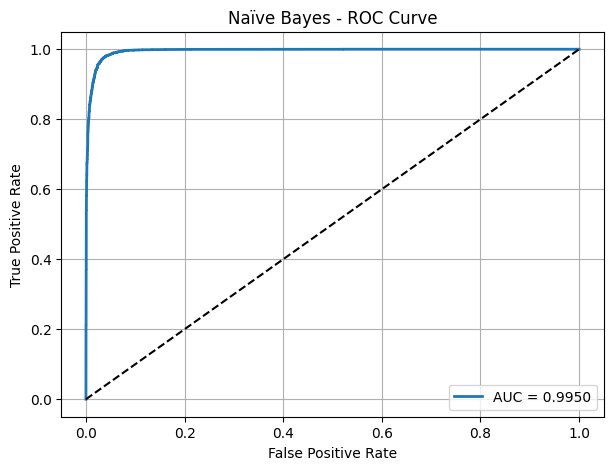

In [26]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    nb_probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {nb_auc:.4f}"
)

plt.plot([0,1], [0,1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Naïve Bayes - ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [27]:
# Save the results

model_results.loc[len(model_results)] = {
    "Model": "Naïve Bayes",
    "Accuracy": nb_accuracy,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1 Score": nb_f1,
    "ROC AUC": nb_auc
}

## Linear Support Vector Machine (LinearSVC)

Train and evaluate the Linear Support Vector Machine (LinearSVC) model using TF-IDF features.

In [28]:
from sklearn.svm import LinearSVC

# Train the LinearSVC model

svm = LinearSVC(random_state=42)

svm.fit(X_train_tfidf, y_train)

LinearSVC(random_state=42)

In [29]:
# Predict the test data

svm_predictions = svm.predict(X_test_tfidf)

# Decision scores for ROC curve

svm_scores = svm.decision_function(X_test_tfidf)

In [30]:
start_time = time.time()

end_time = time.time()

svm_training_time = end_time - start_time

print(f"Training Time: {svm_training_time:.4f} seconds")

Training Time: 0.0000 seconds


In [31]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Calculate evaluation metrics

svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)
svm_auc = roc_auc_score(y_test, svm_scores)

# Display results

metrics = {
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1 Score": svm_f1,
    "ROC AUC": svm_auc
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, svm_predictions))

Accuracy: 0.9880
Precision: 0.9862
Recall: 0.9913
F1 Score: 0.9887
ROC AUC: 0.9987

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      6621
           1       0.99      0.99      0.99      7477

    accuracy                           0.99     14098
   macro avg       0.99      0.99      0.99     14098
weighted avg       0.99      0.99      0.99     14098



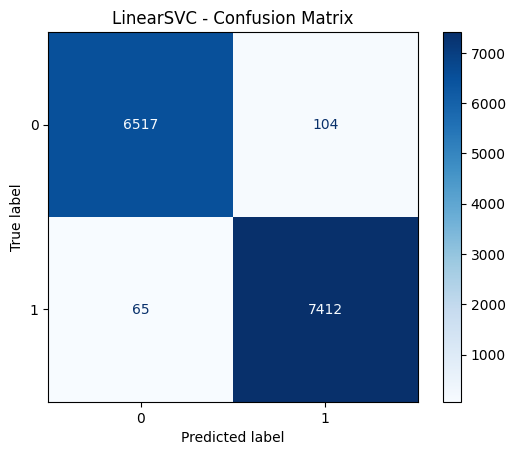

In [32]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    svm_predictions,
    cmap="Blues"
)

plt.title("LinearSVC - Confusion Matrix")

plt.show()

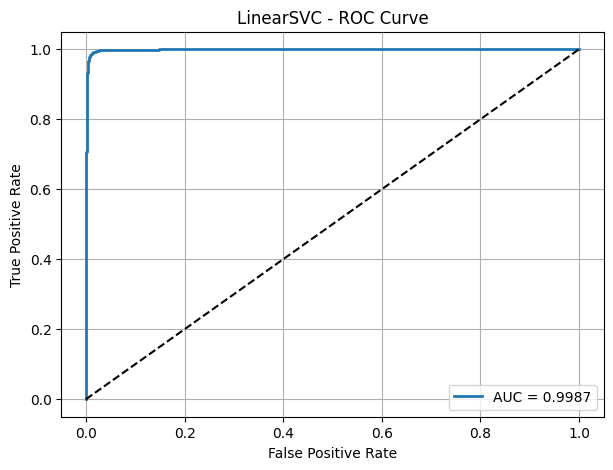

In [33]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    svm_scores
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {svm_auc:.4f}"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("LinearSVC - ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [34]:
# Save the results

model_results.loc[len(model_results)] = {
    "Model": "LinearSVC",
    "Accuracy": svm_accuracy,
    "Precision": svm_precision,
    "Recall": svm_recall,
    "F1 Score": svm_f1,
    "ROC AUC": svm_auc
}

## Random Forest

Train and evaluate the Random Forest classifier using TF-IDF features.

In [35]:
from sklearn.ensemble import RandomForestClassifier

# Train the Random Forest model

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train_tfidf, y_train)

RandomForestClassifier(random_state=42)

In [36]:
# Predict the test data

rf_predictions = rf.predict(X_test_tfidf)

# Predict probabilities for ROC curve

rf_probabilities = rf.predict_proba(X_test_tfidf)[:, 1]

In [37]:
start_time = time.time()

rf.fit(X_train_tfidf, y_train)

end_time = time.time()

rf_training_time = end_time - start_time

print(f"Training Time: {rf_training_time:.4f} seconds")

Training Time: 105.3968 seconds


In [38]:
# Calculate evaluation metrics

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_auc = roc_auc_score(y_test, rf_probabilities)

# Display results

metrics = {
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC AUC": rf_auc
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, rf_predictions))

Accuracy: 0.9848
Precision: 0.9865
Recall: 0.9849
F1 Score: 0.9857
ROC AUC: 0.9980

Classification Report

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      6621
           1       0.99      0.98      0.99      7477

    accuracy                           0.98     14098
   macro avg       0.98      0.98      0.98     14098
weighted avg       0.98      0.98      0.98     14098



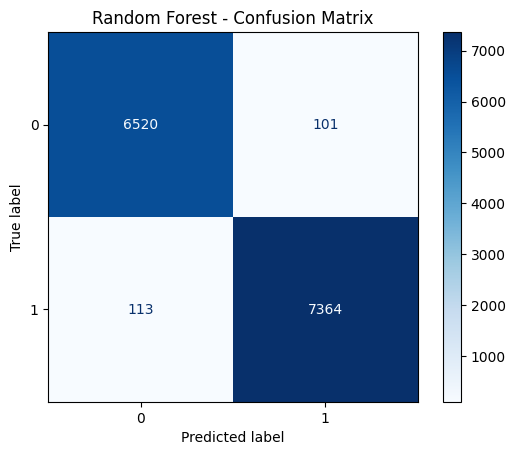

In [39]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")

plt.show()

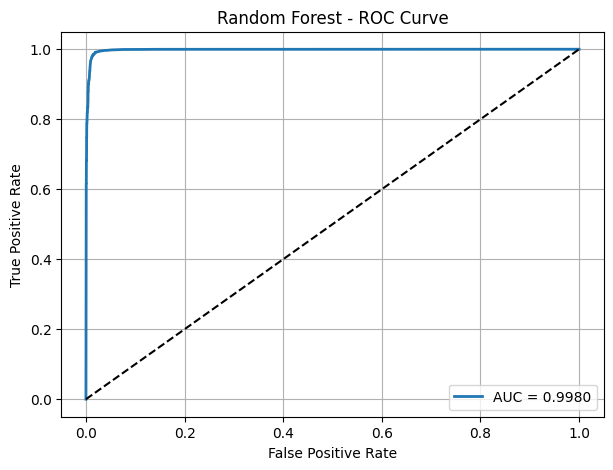

In [40]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {rf_auc:.4f}"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Random Forest - ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [41]:
# Save the results

model_results.loc[len(model_results)] = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1,
    "ROC AUC": rf_auc
}

## XGBoost

Train and evaluate the XGBoost classifier using TF-IDF features.

In [42]:
from xgboost import XGBClassifier

# Train the XGBoost model

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_tfidf, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [43]:
# Predict the test data

xgb_predictions = xgb.predict(X_test_tfidf)

# Predict probabilities for ROC curve

xgb_probabilities = xgb.predict_proba(X_test_tfidf)[:, 1]

In [44]:
# Calculate evaluation metrics

xgb_accuracy = accuracy_score(y_test, xgb_predictions)
xgb_precision = precision_score(y_test, xgb_predictions)
xgb_recall = recall_score(y_test, xgb_predictions)
xgb_f1 = f1_score(y_test, xgb_predictions)
xgb_auc = roc_auc_score(y_test, xgb_probabilities)

# Display results

metrics = {
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC AUC": xgb_auc
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nClassification Report\n")
print(classification_report(y_test, xgb_predictions))

Accuracy: 0.9788
Precision: 0.9690
Recall: 0.9917
F1 Score: 0.9802
ROC AUC: 0.9978

Classification Report

              precision    recall  f1-score   support

           0       0.99      0.96      0.98      6621
           1       0.97      0.99      0.98      7477

    accuracy                           0.98     14098
   macro avg       0.98      0.98      0.98     14098
weighted avg       0.98      0.98      0.98     14098



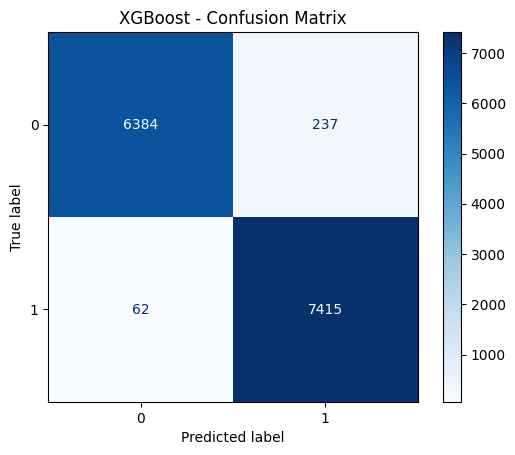

In [45]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    xgb_predictions,
    cmap="Blues"
)

plt.title("XGBoost - Confusion Matrix")

plt.show()

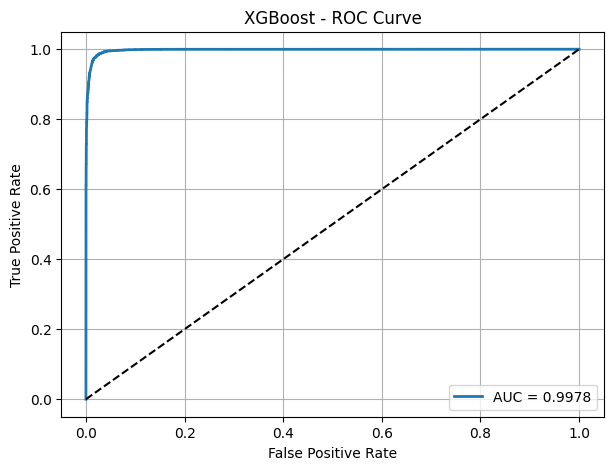

In [46]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    xgb_probabilities
)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {xgb_auc:.4f}"
)

plt.plot([0,1],[0,1],"k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("XGBoost - ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

In [47]:
# Save the results

model_results.loc[len(model_results)] = {
    "Model": "XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1 Score": xgb_f1,
    "ROC AUC": xgb_auc
}

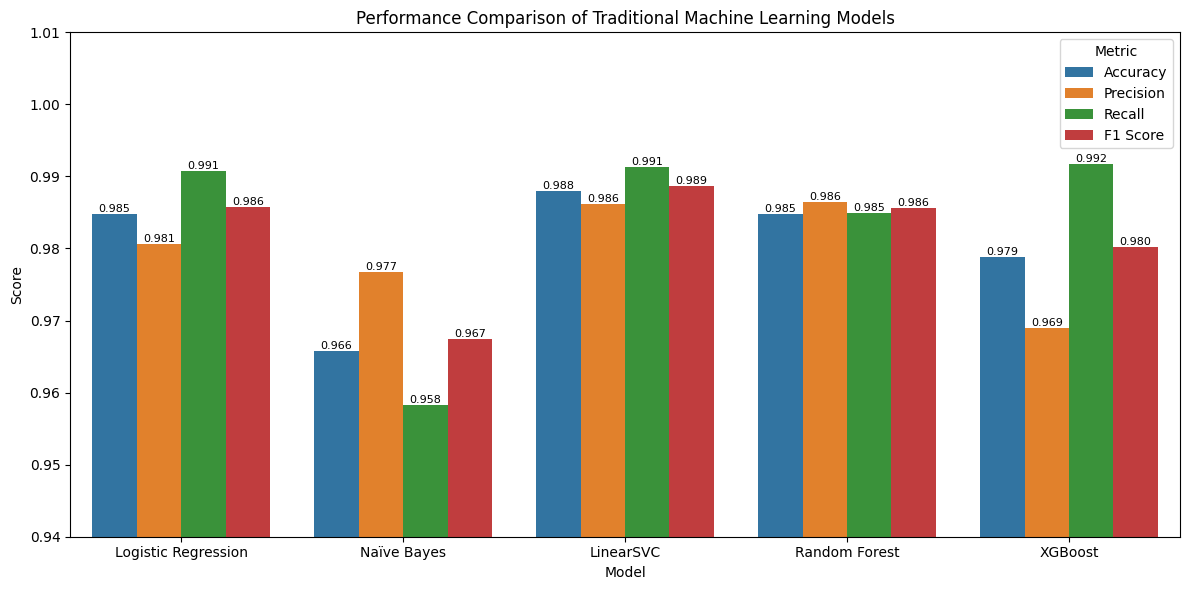

In [48]:
results_plot = model_results.melt(
    id_vars="Model",
    value_vars=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=results_plot,
    x="Model",
    y="Score",
    hue="Metric"
)

plt.title("Performance Comparison of Traditional Machine Learning Models")

plt.ylim(0.94,1.01)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8)

plt.tight_layout()

plt.show()

## ROC Curve Comparison

Compare the Receiver Operating Characteristic (ROC) curves of the traditional machine learning models. The ROC curve illustrates the trade-off between the True Positive Rate (TPR) and the False Positive Rate (FPR), while the Area Under the Curve (AUC) measures the overall classification performance.

In [49]:
from sklearn.metrics import roc_curve

# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probabilities)

# Naïve Bayes
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_probabilities)

# LinearSVC
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores)

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probabilities)

# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probabilities)

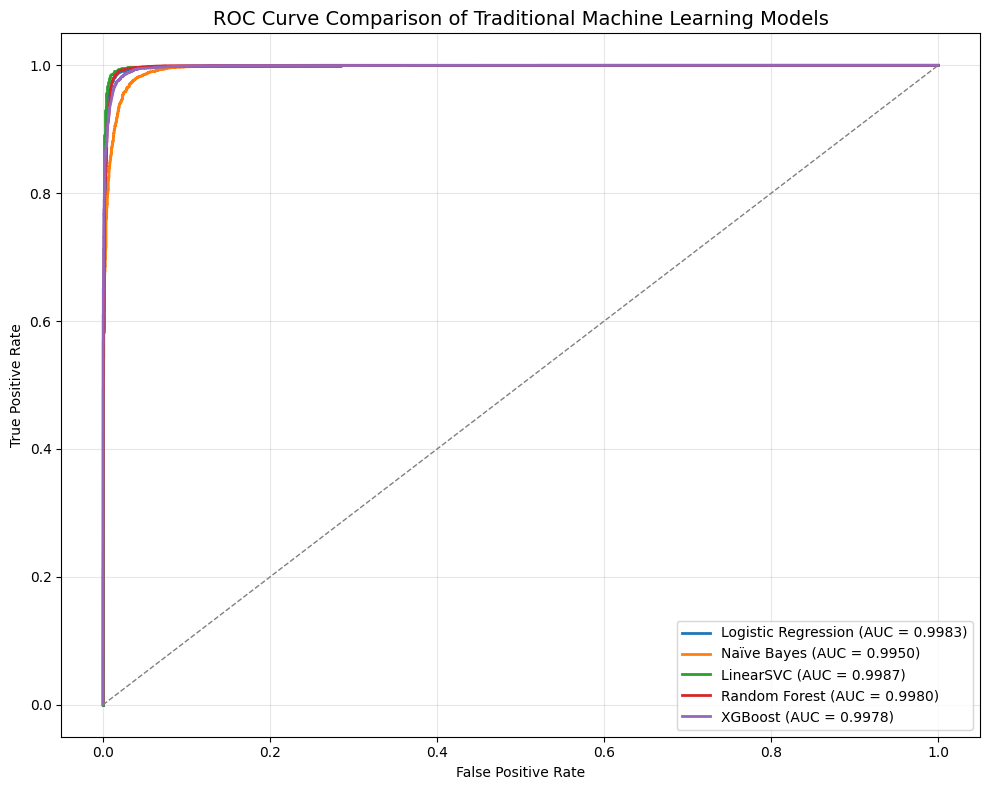

In [50]:
plt.figure(figsize=(10,8))

plt.plot(
    lr_fpr,
    lr_tpr,
    linewidth=2,
    label=f"Logistic Regression (AUC = {lr_auc:.4f})"
)

plt.plot(
    nb_fpr,
    nb_tpr,
    linewidth=2,
    label=f"Naïve Bayes (AUC = {nb_auc:.4f})"
)

plt.plot(
    svm_fpr,
    svm_tpr,
    linewidth=2,
    label=f"LinearSVC (AUC = {svm_auc:.4f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot(
    xgb_fpr,
    xgb_tpr,
    linewidth=2,
    label=f"XGBoost (AUC = {xgb_auc:.4f})"
)

# Random classifier
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray",
    linewidth=1
)

plt.title("ROC Curve Comparison of Traditional Machine Learning Models", fontsize=14)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.tight_layout()

# Experiment 2 - DistilBERT

This experiment evaluates DistilBERT, a transformer-based language model, for phishing email detection. The model is fine-tuned using the same training and testing datasets to enable a fair comparison with the traditional machine learning models.

## Import Required Libraries

Import the libraries required for preparing the dataset, fine-tuning DistilBERT, and evaluating the model.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

## Prepare the Dataset

Use the combined email text and corresponding labels for DistilBERT. The same train-test split used in the traditional machine learning experiment is applied to ensure a fair comparison.

In [52]:
# Create train and test dataframes

train_df = pd.DataFrame({
    "text": X_train.reset_index(drop=True),
    "label": y_train.reset_index(drop=True)
})

test_df = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "label": y_test.reset_index(drop=True)
})

print("Training samples:", len(train_df))
print("Testing samples :", len(test_df))

train_df.head()

Training samples: 56388
Testing samples : 14098


,text,label
0,Re: [Python-3000] [stdlib-sig] PEP 3108 - stdl...,0
1,off shors account ready - accordant dispensabl...,1
2,porno dvd Kick-up for 8ac78fe31e07dc797a3c6e86...,1
3,Re: [opensuse] kismet and ipw 3945 On Donnerst...,0
4,bayer - march 2001 volumes just want to make s...,0


## Load the DistilBERT Tokenizer

Load the pre-trained DistilBERT tokenizer to convert email text into token IDs.

In [53]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

print("Tokenizer loaded successfully.")

Tokenizer loaded successfully.


## Create a Custom Dataset

Create a custom PyTorch dataset to tokenize the email text and prepare it for model training.

In [54]:
class EmailDataset(Dataset):

    def __init__(self, texts, labels):

        self.texts = texts.tolist()
        self.labels = labels.tolist()

    def __len__(self):

        return len(self.texts)

    def __getitem__(self, idx):

        encoding = tokenizer(

            self.texts[idx],

            truncation=True,

            padding="max_length",

            max_length=256,

            return_tensors="pt"

        )

        return {

            "input_ids": encoding["input_ids"].squeeze(0),

            "attention_mask": encoding["attention_mask"].squeeze(0),

            "labels": torch.tensor(
                self.labels[idx],
                dtype=torch.long
            )
        }

## Create Training and Testing Datasets

Convert the training and testing data into PyTorch datasets.

In [55]:
train_dataset = EmailDataset(
    train_df["text"],
    train_df["label"]
)

test_dataset = EmailDataset(
    test_df["text"],
    test_df["label"]
)

print("Training Dataset:", len(train_dataset))
print("Testing Dataset :", len(test_dataset))

Training Dataset: 56388
Testing Dataset : 14098


## Create DataLoaders

Create DataLoaders to process the datasets in batches during training and evaluation.

In [56]:
train_loader = DataLoader(

    train_dataset,

    batch_size=16,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=16,

    shuffle=False

)

## Load the DistilBERT Model

Load the pre-trained DistilBERT model and move it to the available device (GPU if available, otherwise CPU).

In [57]:
# Select the available device

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [58]:
# Load the pre-trained DistilBERT model

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

model.to(device)

print("Model loaded successfully.")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.


## Define the Optimizer

Configure the AdamW optimizer to fine-tune the DistilBERT model.

In [59]:
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)

## Train the DistilBERT Model

Fine-tune the DistilBERT model using the training dataset.

In [60]:
# Number of training epochs

epochs = 2

for epoch in range(epochs):

    model.train()

    total_loss = 0

    print(f"\nEpoch {epoch+1}/{epochs}")

    for batch in train_loader:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)

        attention_mask = batch["attention_mask"].to(device)

        labels = batch["labels"].to(device)

        outputs = model(

            input_ids=input_ids,

            attention_mask=attention_mask,

            labels=labels

        )

        loss = outputs.loss

        total_loss += loss.item()

        loss.backward()

        optimizer.step()

    average_loss = total_loss / len(train_loader)

    print(f"Training Loss: {average_loss:.4f}")


Epoch 1/2
Training Loss: 0.0458

Epoch 2/2
Training Loss: 0.0099


## Generate Predictions

Use the fine-tuned DistilBERT model to predict the labels of the testing dataset.

In [61]:
# Put the model into evaluation mode

model.eval()

predictions = []
probabilities = []
true_labels = []

with torch.no_grad():

    for batch in test_loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits

        probs = torch.softmax(logits, dim=1)

        preds = torch.argmax(probs, dim=1)

        predictions.extend(preds.cpu().numpy())

        probabilities.extend(probs[:, 1].cpu().numpy())

        true_labels.extend(labels.cpu().numpy())

print("Predictions generated successfully.")

Predictions generated successfully.


## Evaluate the DistilBERT Model

Calculate the evaluation metrics using the testing dataset.

In [62]:
distilbert_accuracy = accuracy_score(
    true_labels,
    predictions
)

distilbert_precision = precision_score(
    true_labels,
    predictions
)

distilbert_recall = recall_score(
    true_labels,
    predictions
)

distilbert_f1 = f1_score(
    true_labels,
    predictions
)

distilbert_auc = roc_auc_score(
    true_labels,
    probabilities
)

print(f"Accuracy : {distilbert_accuracy:.4f}")
print(f"Precision: {distilbert_precision:.4f}")
print(f"Recall   : {distilbert_recall:.4f}")
print(f"F1 Score : {distilbert_f1:.4f}")
print(f"ROC AUC  : {distilbert_auc:.4f}")

Accuracy : 0.9944
Precision: 0.9953
Recall   : 0.9941
F1 Score : 0.9947
ROC AUC  : 0.9998


## Classification Report

Display the detailed classification report for DistilBERT.

In [63]:
print(classification_report(
    true_labels,
    predictions
))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6621
           1       1.00      0.99      0.99      7477

    accuracy                           0.99     14098
   macro avg       0.99      0.99      0.99     14098
weighted avg       0.99      0.99      0.99     14098



## Confusion Matrix

Visualise the confusion matrix for DistilBERT.

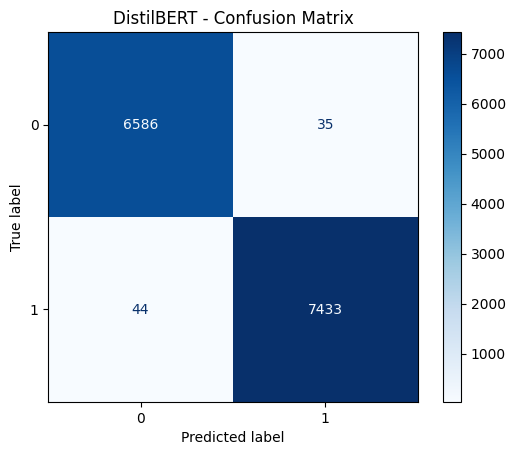

In [64]:
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    predictions,
    cmap="Blues"
)

plt.title("DistilBERT - Confusion Matrix")

plt.show()

## ROC Curve

Plot the Receiver Operating Characteristic (ROC) curve for DistilBERT.

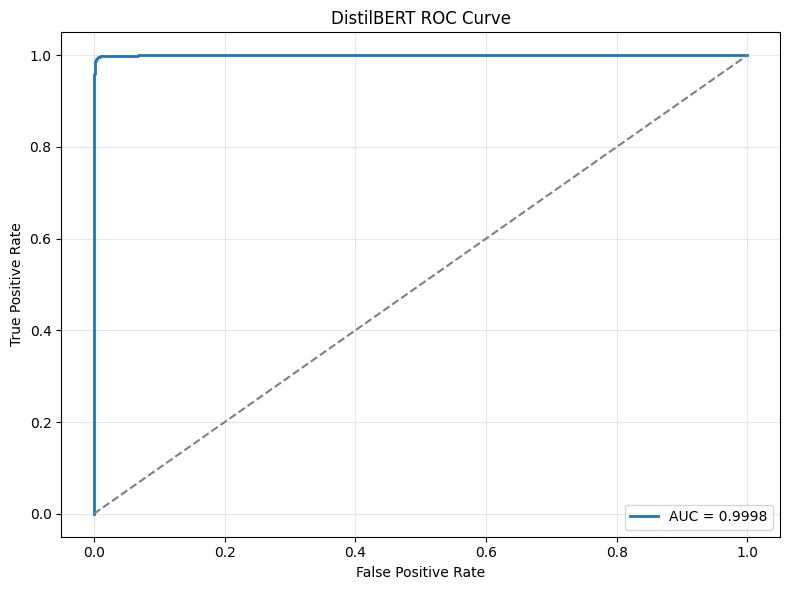

In [65]:
fpr, tpr, _ = roc_curve(
    true_labels,
    probabilities
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {distilbert_auc:.4f}"
)

plt.plot([0,1], [0,1], "--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("DistilBERT ROC Curve")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## Save the Results

Store the DistilBERT evaluation metrics for comparison with the traditional machine learning models.

In [66]:
model_results.loc[len(model_results)] = {

    "Model": "DistilBERT",

    "Accuracy": distilbert_accuracy,

    "Precision": distilbert_precision,

    "Recall": distilbert_recall,

    "F1 Score": distilbert_f1,

    "ROC AUC": distilbert_auc
}

model_results = model_results.round(4)

model_results.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Training Time (s)
0,DistilBERT,0.9944,0.9953,0.9941,0.9947,0.9998,NaN
1,LinearSVC,0.9880,0.9862,0.9913,0.9887,0.9987,NaN
2,Random Forest,0.9848,0.9865,0.9849,0.9857,0.9980,NaN
3,Logistic Regression,0.9847,0.9807,0.9908,0.9857,0.9983,NaN
4,XGBoost,0.9788,0.9690,0.9917,0.9802,0.9978,NaN
5,Naïve Bayes,0.9657,0.9767,0.9583,0.9674,0.9950,NaN
